# H&E histological patch classification

**Members:** Théo, Jehan, Matthieu

This notebook rebuilds the project workflow from the beginning:

1. data exploration,
2. image loading and preprocessing with `skimage`,
3. handmade feature extraction with NumPy only,
4. classification with four selected machine learning models,
5. prediction code for the future test dataset.

Important rule followed here: `skimage` is used for image import, grayscale
conversion, Otsu thresholding and simple mask preparation. The feature values
are not extracted with `skimage.feature`, `skimage.measure`, `regionprops`, or
any ready-made descriptor extractor. All descriptors are computed manually with
NumPy operations.


## Imports and paths

The paths below follow the same organization as the previous project notebook.
If your folders have different names, only edit this first code cell.


In [1]:
import warnings
warnings.simplefilter("ignore")

import os
import shutil
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from skimage import color, exposure, filters, io, morphology, util

from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, VarianceThreshold
from sklearn.feature_selection import f_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.model_selection import cross_val_predict
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

RANDOM_STATE = 42
N_EXAMPLES_PER_CLASS = 5

CWD = os.getcwd()
ROOT_DIR = CWD

DATA_DIR = os.path.join(ROOT_DIR, "data")
TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
TRAIN_IMG_DIR = os.path.join(DATA_DIR, "datasetjehan")
TEST_IMG_DIR = os.path.join(DATA_DIR, "tdatasetJehan")

QUALITY_DIR = os.path.join(DATA_DIR, "quality_control")
FIG_DIR = os.path.join(DATA_DIR, "figures")
FEATURES_TRAIN_CSV = os.path.join(DATA_DIR, "features_train.csv")
MODEL_PATH = os.path.join(DATA_DIR, "best_model.joblib")
TEST_OUTPUT_CSV = os.path.join(DATA_DIR, "test.csv")

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(QUALITY_DIR, exist_ok=True)

print("Current working directory:", CWD)

Current working directory: /workspaces/cell_classification/src


## Part I — Data exploration

We first load the training CSV, check the number of samples, inspect the label
distribution, create a quality-control folder, and display a few examples per
class. This step helps us understand the visual differences between classes and
therefore choose meaningful features.


Total samples: 400
Labels: ['Fibroblast', 'Lymphocyte', 'Plasma', 'Tumor']


,count
Label,
Fibroblast,100
Lymphocyte,100
Plasma,100
Tumor,100


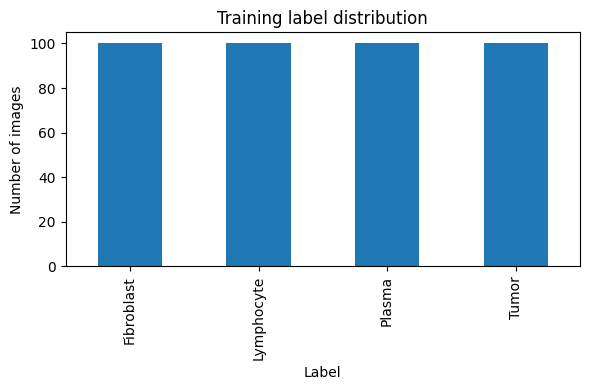

Imbalance ratio, max/min: 1.00


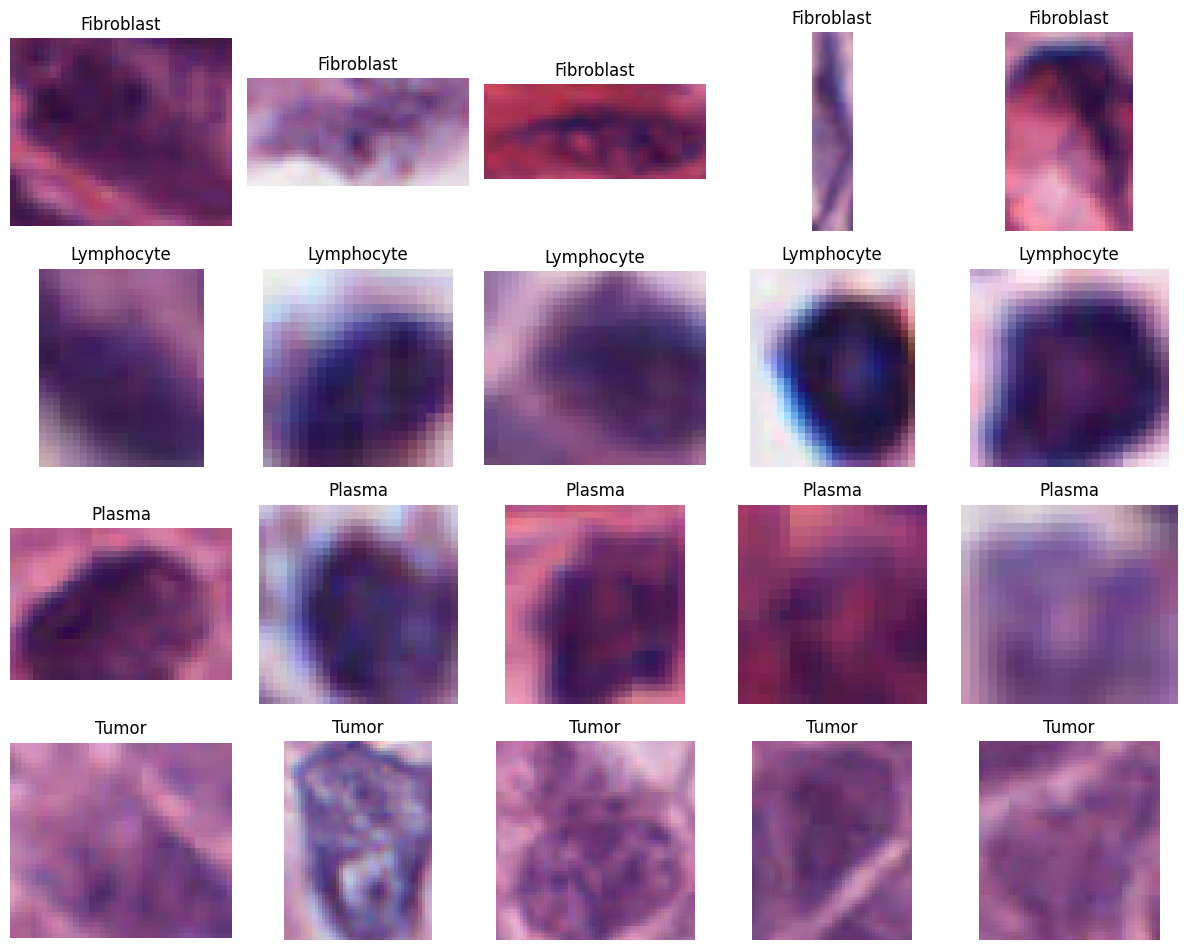

In [2]:
def find_image_path(img_id, img_dir):
    """Return the path of an image identifier, trying common extensions."""
    extensions = [".png", ".jpg", ".jpeg", ".tif", ".tiff"]
    for ext in extensions:
        candidate = os.path.join(img_dir, f"{img_id}{ext}")
        if os.path.exists(candidate):
            return candidate
    return None


def read_rgb_image(path):
    """Read an image with skimage and return an RGB uint8 array."""
    img = io.imread(path)

    if img.ndim == 2:
        img = np.stack([img, img, img], axis=-1)

    if img.shape[-1] == 4:
        img = img[:, :, :3]

    if np.issubdtype(img.dtype, np.floating):
        img = util.img_as_ubyte(np.clip(img, 0, 1))
    else:
        img = np.clip(img, 0, 255).astype(np.uint8)

    return img


train_df = pd.read_csv(TRAIN_CSV)

num_samples = len(train_df)
label_names = sorted(train_df["Label"].unique())
label_counts = train_df["Label"].value_counts().reindex(label_names)

print(f"Total samples: {num_samples}")
print(f"Labels: {label_names}")
display(label_counts.to_frame(name="count"))

plt.figure(figsize=(6, 4))
label_counts.plot(kind="bar")
plt.title("Training label distribution")
plt.xlabel("Label")
plt.ylabel("Number of images")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "label_distribution.png"))
plt.show()

imbalance_ratio = label_counts.max() / label_counts.min()
print(f"Imbalance ratio, max/min: {imbalance_ratio:.2f}")

for label in label_names:
    label_dir = os.path.join(QUALITY_DIR, str(label))
    os.makedirs(label_dir, exist_ok=True)

for _, row in train_df.iterrows():
    img_path = find_image_path(row["Image"], TRAIN_IMG_DIR)
    if img_path is None:
        continue

    dst_path = os.path.join(
        QUALITY_DIR,
        str(row["Label"]),
        os.path.basename(img_path),
    )
    if not os.path.exists(dst_path):
        shutil.copyfile(img_path, dst_path)

np.random.seed(RANDOM_STATE)
fig, axes = plt.subplots(
    len(label_names),
    N_EXAMPLES_PER_CLASS,
    figsize=(12, 2.4 * len(label_names)),
)

if len(label_names) == 1:
    axes = np.array([axes])

for i, label in enumerate(label_names):
    subset = train_df[train_df["Label"] == label]
    n_show = min(N_EXAMPLES_PER_CLASS, len(subset))
    sample_rows = subset.sample(n=n_show, random_state=RANDOM_STATE)

    for j in range(N_EXAMPLES_PER_CLASS):
        ax = axes[i, j]
        ax.axis("off")

        if j >= n_show:
            continue

        row = sample_rows.iloc[j]
        img_path = find_image_path(row["Image"], TRAIN_IMG_DIR)
        if img_path is None:
            ax.set_title("Missing")
            continue

        ax.imshow(read_rgb_image(img_path))
        ax.set_title(str(label))

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "examples_grid.png"))
plt.show()

### Visual interpretation

Write your final observations after running the cell above. A simple expected
analysis is:

- how many samples are available,
- whether the classes are balanced,
- what each cell class usually looks like,
- which classes look easier or harder to separate.

For this kind of histological dataset, useful visual clues are often size,
shape, darkness, blue/red color balance, and texture.


## Part II — Feature extraction

### Easy NumPy features that can be useful

Many simple descriptors can be implemented with NumPy only:

- **area:** foreground ratio, main object area, bounding-box area;
- **shape:** aspect ratio, extent, compactness, elongation, eccentricity;
- **position:** centroid coordinates, horizontal and vertical spread;
- **perimeter:** number of boundary pixels, perimeter normalized by image size;
- **intensity:** mean, standard deviation, median, percentiles, dark-pixel ratio;
- **color:** channel means, channel standard deviations, blue/red ratio,
  blue-minus-red index, red-plus-green index;
- **texture:** homemade GLCM contrast, homogeneity, energy, entropy,
  correlation, local 3x3 variance;
- **robustness checks:** missing-image flags, empty-mask fallback values.

The code below computes more descriptors than we finally use for ML. In Part
III we select a compact subset of 17 features to stay in the 11–17 feature
range requested for a dataset of around 400 images.


In [3]:
def preprocess_image(rgb):
    """Prepare grayscale image and tissue mask using skimage.

    skimage is used here only for import/preprocessing: grayscale conversion,
    contrast rescaling, Otsu thresholding and small binary clean-up.
    """
    rgb_float = util.img_as_float(rgb)
    gray = color.rgb2gray(rgb_float)
    gray = exposure.rescale_intensity(gray, in_range="image")

    try:
        threshold = filters.threshold_otsu(gray)
    except ValueError:
        threshold = float(np.mean(gray))

    mask = gray < threshold

    ratio = float(mask.mean())
    if ratio < 0.01 or ratio > 0.95:
        mask = gray < np.percentile(gray, 70)

    footprint_1 = morphology.disk(1)
    footprint_2 = morphology.disk(2)
    mask = morphology.binary_opening(mask, footprint=footprint_1)
    mask = morphology.binary_closing(mask, footprint=footprint_2)
    mask = morphology.remove_small_objects(mask.astype(bool), min_size=16)
    mask = morphology.remove_small_holes(mask.astype(bool), area_threshold=16)

    if mask.sum() == 0:
        mask = gray < np.percentile(gray, 50)

    return rgb_float, gray.astype(np.float32), mask.astype(bool)


def connected_components_np(mask):
    """Label 8-connected components with plain Python/NumPy logic."""
    mask = mask.astype(bool)
    height, width = mask.shape
    labels = np.zeros((height, width), dtype=np.int32)
    sizes = []
    current_label = 0

    for row in range(height):
        for col in range(width):
            if not mask[row, col] or labels[row, col] != 0:
                continue

            current_label += 1
            labels[row, col] = current_label
            stack = [(row, col)]
            size = 0

            while stack:
                r, c = stack.pop()
                size += 1

                for dr in (-1, 0, 1):
                    for dc in (-1, 0, 1):
                        if dr == 0 and dc == 0:
                            continue

                        rr = r + dr
                        cc = c + dc

                        if rr < 0 or rr >= height:
                            continue
                        if cc < 0 or cc >= width:
                            continue
                        if not mask[rr, cc] or labels[rr, cc] != 0:
                            continue

                        labels[rr, cc] = current_label
                        stack.append((rr, cc))

            sizes.append(size)

    return labels, np.array(sizes, dtype=np.int32)


def largest_component_np(mask):
    """Keep the largest connected component using NumPy-based labels."""
    labels, sizes = connected_components_np(mask)
    if len(sizes) == 0:
        return mask.astype(bool)

    largest_label = int(np.argmax(sizes) + 1)
    return labels == largest_label


def perimeter_np(mask):
    """Count boundary pixels with 4-neighborhood comparisons."""
    mask = mask.astype(bool)
    padded = np.pad(mask, pad_width=1, mode="constant")
    center = padded[1:-1, 1:-1]
    up = padded[:-2, 1:-1]
    down = padded[2:, 1:-1]
    left = padded[1:-1, :-2]
    right = padded[1:-1, 2:]

    boundary = center & (~up | ~down | ~left | ~right)
    return int(boundary.sum())


def safe_mask_values(array, mask):
    """Return values inside mask; fallback to full image if mask is empty."""
    values = array[mask]
    if values.size == 0:
        values = array.ravel()
    return values.astype(np.float64)


def area_shape_perimeter_features(mask):
    """Compute handmade area, shape and perimeter descriptors."""
    height, width = mask.shape
    total_pixels = height * width
    main = largest_component_np(mask)

    coords = np.column_stack(np.nonzero(main))
    area_pixels = int(main.sum())
    foreground_pixels = int(mask.sum())
    eps = 1e-8

    if area_pixels == 0:
        return {
            "area_ratio": 0.0,
            "main_area_ratio": 0.0,
            "perimeter_ratio": 0.0,
            "bbox_aspect_ratio": 0.0,
            "bbox_extent": 0.0,
            "compactness": 0.0,
            "eccentricity": 0.0,
            "elongation": 0.0,
            "centroid_x_norm": 0.5,
            "centroid_y_norm": 0.5,
        }

    rows = coords[:, 0]
    cols = coords[:, 1]
    row_min, row_max = rows.min(), rows.max()
    col_min, col_max = cols.min(), cols.max()
    bbox_h = row_max - row_min + 1
    bbox_w = col_max - col_min + 1
    bbox_area = bbox_h * bbox_w

    centroid_y = float(rows.mean() / max(height - 1, 1))
    centroid_x = float(cols.mean() / max(width - 1, 1))

    if len(coords) >= 2:
        centered = coords.astype(np.float64) - coords.mean(axis=0)
        cov = np.cov(centered.T) + eps * np.eye(2)
        eigvals = np.linalg.eigvalsh(cov)
        eigvals = np.maximum(eigvals, eps)
        major = float(np.sqrt(eigvals.max()))
        minor = float(np.sqrt(eigvals.min()))
        elongation = major / (minor + eps)
        eccentricity = np.sqrt(1.0 - eigvals.min() / eigvals.max())
    else:
        elongation = 1.0
        eccentricity = 0.0

    perimeter = perimeter_np(main)
    compactness = 4.0 * np.pi * area_pixels / ((perimeter + eps) ** 2)

    return {
        "area_ratio": foreground_pixels / total_pixels,
        "main_area_ratio": area_pixels / total_pixels,
        "perimeter_ratio": perimeter / total_pixels,
        "bbox_aspect_ratio": bbox_w / (bbox_h + eps),
        "bbox_extent": area_pixels / (bbox_area + eps),
        "compactness": float(compactness),
        "eccentricity": float(eccentricity),
        "elongation": float(elongation),
        "centroid_x_norm": centroid_x,
        "centroid_y_norm": centroid_y,
    }


def intensity_color_features(rgb_float, gray, mask):
    """Compute intensity and RGB descriptors with NumPy."""
    gray_vals = safe_mask_values(gray, mask)
    red_vals = safe_mask_values(rgb_float[:, :, 0], mask)
    green_vals = safe_mask_values(rgb_float[:, :, 1], mask)
    blue_vals = safe_mask_values(rgb_float[:, :, 2], mask)

    eps = 1e-8
    return {
        "gray_mean": float(np.mean(gray_vals)),
        "gray_std": float(np.std(gray_vals)),
        "gray_median": float(np.median(gray_vals)),
        "gray_p10": float(np.percentile(gray_vals, 10)),
        "gray_p90": float(np.percentile(gray_vals, 90)),
        "dark_pixel_ratio": float(np.mean(gray_vals < np.percentile(gray, 25))),
        "red_mean": float(np.mean(red_vals)),
        "green_mean": float(np.mean(green_vals)),
        "blue_mean": float(np.mean(blue_vals)),
        "red_std": float(np.std(red_vals)),
        "green_std": float(np.std(green_vals)),
        "blue_std": float(np.std(blue_vals)),
        "blue_red_ratio": float(np.mean(blue_vals) / (np.mean(red_vals) + eps)),
        "hematoxylin_index": float(np.mean(blue_vals - red_vals)),
        "eosin_index": float(np.mean(red_vals + green_vals) / 2.0),
    }


def quantize_gray_np(gray, levels=32):
    """Quantize grayscale values between 0 and levels - 1."""
    gray_norm = np.clip(gray, 0, 1)
    return np.floor(gray_norm * (levels - 1)).astype(np.int32)


def glcm_np(gray_q, levels=32):
    """Build simple symmetric GLCMs for four directions using NumPy."""
    offsets = [(0, 1), (1, 0), (1, 1), (-1, 1)]
    matrices = []

    for dr, dc in offsets:
        if dr >= 0:
            src_r = slice(0, gray_q.shape[0] - dr)
            dst_r = slice(dr, gray_q.shape[0])
        else:
            src_r = slice(-dr, gray_q.shape[0])
            dst_r = slice(0, gray_q.shape[0] + dr)

        if dc >= 0:
            src_c = slice(0, gray_q.shape[1] - dc)
            dst_c = slice(dc, gray_q.shape[1])
        else:
            src_c = slice(-dc, gray_q.shape[1])
            dst_c = slice(0, gray_q.shape[1] + dc)

        src = gray_q[src_r, src_c].ravel()
        dst = gray_q[dst_r, dst_c].ravel()

        matrix = np.zeros((levels, levels), dtype=np.float64)
        np.add.at(matrix, (src, dst), 1)
        np.add.at(matrix, (dst, src), 1)

        if matrix.sum() > 0:
            matrix /= matrix.sum()

        matrices.append(matrix)

    return np.stack(matrices, axis=0)


def glcm_properties_np(glcms):
    """Compute homemade texture descriptors from GLCMs."""
    levels = glcms.shape[1]
    i, j = np.indices((levels, levels))
    eps = 1e-12

    contrast_values = []
    homogeneity_values = []
    energy_values = []
    entropy_values = []
    correlation_values = []

    for matrix in glcms:
        contrast_values.append(np.sum(matrix * (i - j) ** 2))
        homogeneity_values.append(np.sum(matrix / (1.0 + np.abs(i - j))))
        energy_values.append(np.sqrt(np.sum(matrix ** 2)))
        entropy_values.append(-np.sum(matrix * np.log2(matrix + eps)))

        px = matrix.sum(axis=1)
        py = matrix.sum(axis=0)
        mux = np.sum(np.arange(levels) * px)
        muy = np.sum(np.arange(levels) * py)
        sigx = np.sqrt(np.sum(((np.arange(levels) - mux) ** 2) * px))
        sigy = np.sqrt(np.sum(((np.arange(levels) - muy) ** 2) * py))
        corr = np.sum((i - mux) * (j - muy) * matrix)
        corr = corr / (sigx * sigy + eps)
        correlation_values.append(corr)

    return {
        "texture_contrast": float(np.mean(contrast_values)),
        "texture_homogeneity": float(np.mean(homogeneity_values)),
        "texture_energy": float(np.mean(energy_values)),
        "texture_entropy": float(np.mean(entropy_values)),
        "texture_correlation": float(np.mean(correlation_values)),
    }


def local_variance_3x3_np(gray):
    """Compute local 3x3 variance using only NumPy slicing."""
    height, width = gray.shape
    padded = np.pad(gray, pad_width=1, mode="reflect")
    patches = []

    for dr in range(3):
        for dc in range(3):
            patch = padded[dr:dr + height, dc:dc + width]
            patches.append(patch)

    stack = np.stack(patches, axis=0)
    return np.var(stack, axis=0)


def texture_features(gray, mask):
    """Compute handmade texture descriptors with NumPy."""
    values = safe_mask_values(gray, mask)
    fill_value = float(np.median(values))
    gray_for_texture = gray.copy()
    gray_for_texture[~mask] = fill_value

    gray_q = quantize_gray_np(gray_for_texture, levels=32)
    glcms = glcm_np(gray_q, levels=32)
    features = glcm_properties_np(glcms)

    local_var = local_variance_3x3_np(gray_for_texture)
    local_values = safe_mask_values(local_var, mask)
    features.update({
        "texture_local_var_mean": float(np.mean(local_values)),
        "texture_local_var_std": float(np.std(local_values)),
    })
    return features


def extract_features_from_path(img_path):
    """Extract all handmade features from one image."""
    rgb = read_rgb_image(img_path)
    rgb_float, gray, mask = preprocess_image(rgb)

    features = {}
    features.update(area_shape_perimeter_features(mask))
    features.update(intensity_color_features(rgb_float, gray, mask))
    features.update(texture_features(gray, mask))
    return features


def build_feature_table(df, image_dir, include_labels=True):
    """Extract features for all image identifiers in a dataframe."""
    rows = []
    n_total = len(df)

    for count, (_, row) in enumerate(df.iterrows(), start=1):
        img_id = row["Image"]
        img_path = find_image_path(img_id, image_dir)

        if img_path is None:
            print(f"Missing image: {img_id}")
            continue

        try:
            feature_row = extract_features_from_path(img_path)
        except Exception as exc:
            print(f"Error with image {img_id}: {exc}")
            continue

        feature_row["Image"] = img_id
        if include_labels:
            feature_row["Label"] = row["Label"]

        rows.append(feature_row)

        if count % 50 == 0 or count == n_total:
            print(f"Processed {count}/{n_total} images")

    return pd.DataFrame(rows)


FORCE_RECOMPUTE_FEATURES = True

if os.path.exists(FEATURES_TRAIN_CSV) and not FORCE_RECOMPUTE_FEATURES:
    features_df = pd.read_csv(FEATURES_TRAIN_CSV)
else:
    features_df = build_feature_table(
        train_df,
        TRAIN_IMG_DIR,
        include_labels=True,
    )
    features_df.to_csv(FEATURES_TRAIN_CSV, index=False)

print(f"Feature table saved to: {FEATURES_TRAIN_CSV}")
display(features_df.head())
print("Number of extracted numeric features:",
      len([c for c in features_df.columns if c not in ["Image", "Label"]]))

Missing image: 0
Missing image: 1
Missing image: 2
Missing image: 3
Missing image: 4
Missing image: 5
Missing image: 6
Missing image: 7
Missing image: 8
Missing image: 9
Processed 50/400 images
Processed 100/400 images
Processed 150/400 images
Processed 200/400 images
Processed 250/400 images
Processed 300/400 images
Processed 350/400 images
Processed 400/400 images
Feature table saved to: /workspaces/cell_classification/src/data/features_train.csv


,area_ratio,main_area_ratio,perimeter_ratio,bbox_aspect_ratio,bbox_extent,compactness,eccentricity,elongation,centroid_x_norm,centroid_y_norm,...,eosin_index,texture_contrast,texture_homogeneity,texture_energy,texture_entropy,texture_correlation,texture_local_var_mean,texture_local_var_std,Image,Label
0,0.594286,0.594286,0.077551,1.032258,0.733871,1.013664,0.666338,1.341112,0.546178,0.568035,...,0.489943,3.163482,0.686672,0.382053,5.114708,0.824073,0.002957,0.002651,10,Fibroblast
1,0.570346,0.570346,0.081169,1.333333,0.686198,1.177329,0.811618,1.711777,0.578273,0.631035,...,0.154496,2.308177,0.760677,0.469880,3.784235,0.635070,0.001694,0.003027,11,Lymphocyte
2,0.675641,0.675641,0.100000,0.758621,0.826019,1.088507,0.648018,1.312982,0.622011,0.548060,...,0.197548,6.095872,0.703782,0.390259,4.500257,0.590860,0.003263,0.005420,12,Lymphocyte
3,0.569304,0.569304,0.113623,1.000000,0.569304,0.329652,0.564968,1.211956,0.593600,0.602038,...,0.429684,1.963457,0.725523,0.420373,4.539117,0.795608,0.001827,0.001574,13,Tumor
4,0.679233,0.679233,0.091931,2.160000,0.760741,0.667960,0.867271,2.008695,0.451507,0.616142,...,0.642734,2.557440,0.658118,0.316422,5.435849,0.856684,0.002442,0.002214,14,Fibroblast


Number of extracted numeric features: 32


### Feature visualization

This cell visualizes the numerical descriptors, including texture descriptors.
Boxplots help us see which descriptors are discriminative by class. The
correlation matrix helps us detect redundant features. The PCA plot is only for
visualization, not for final classification.


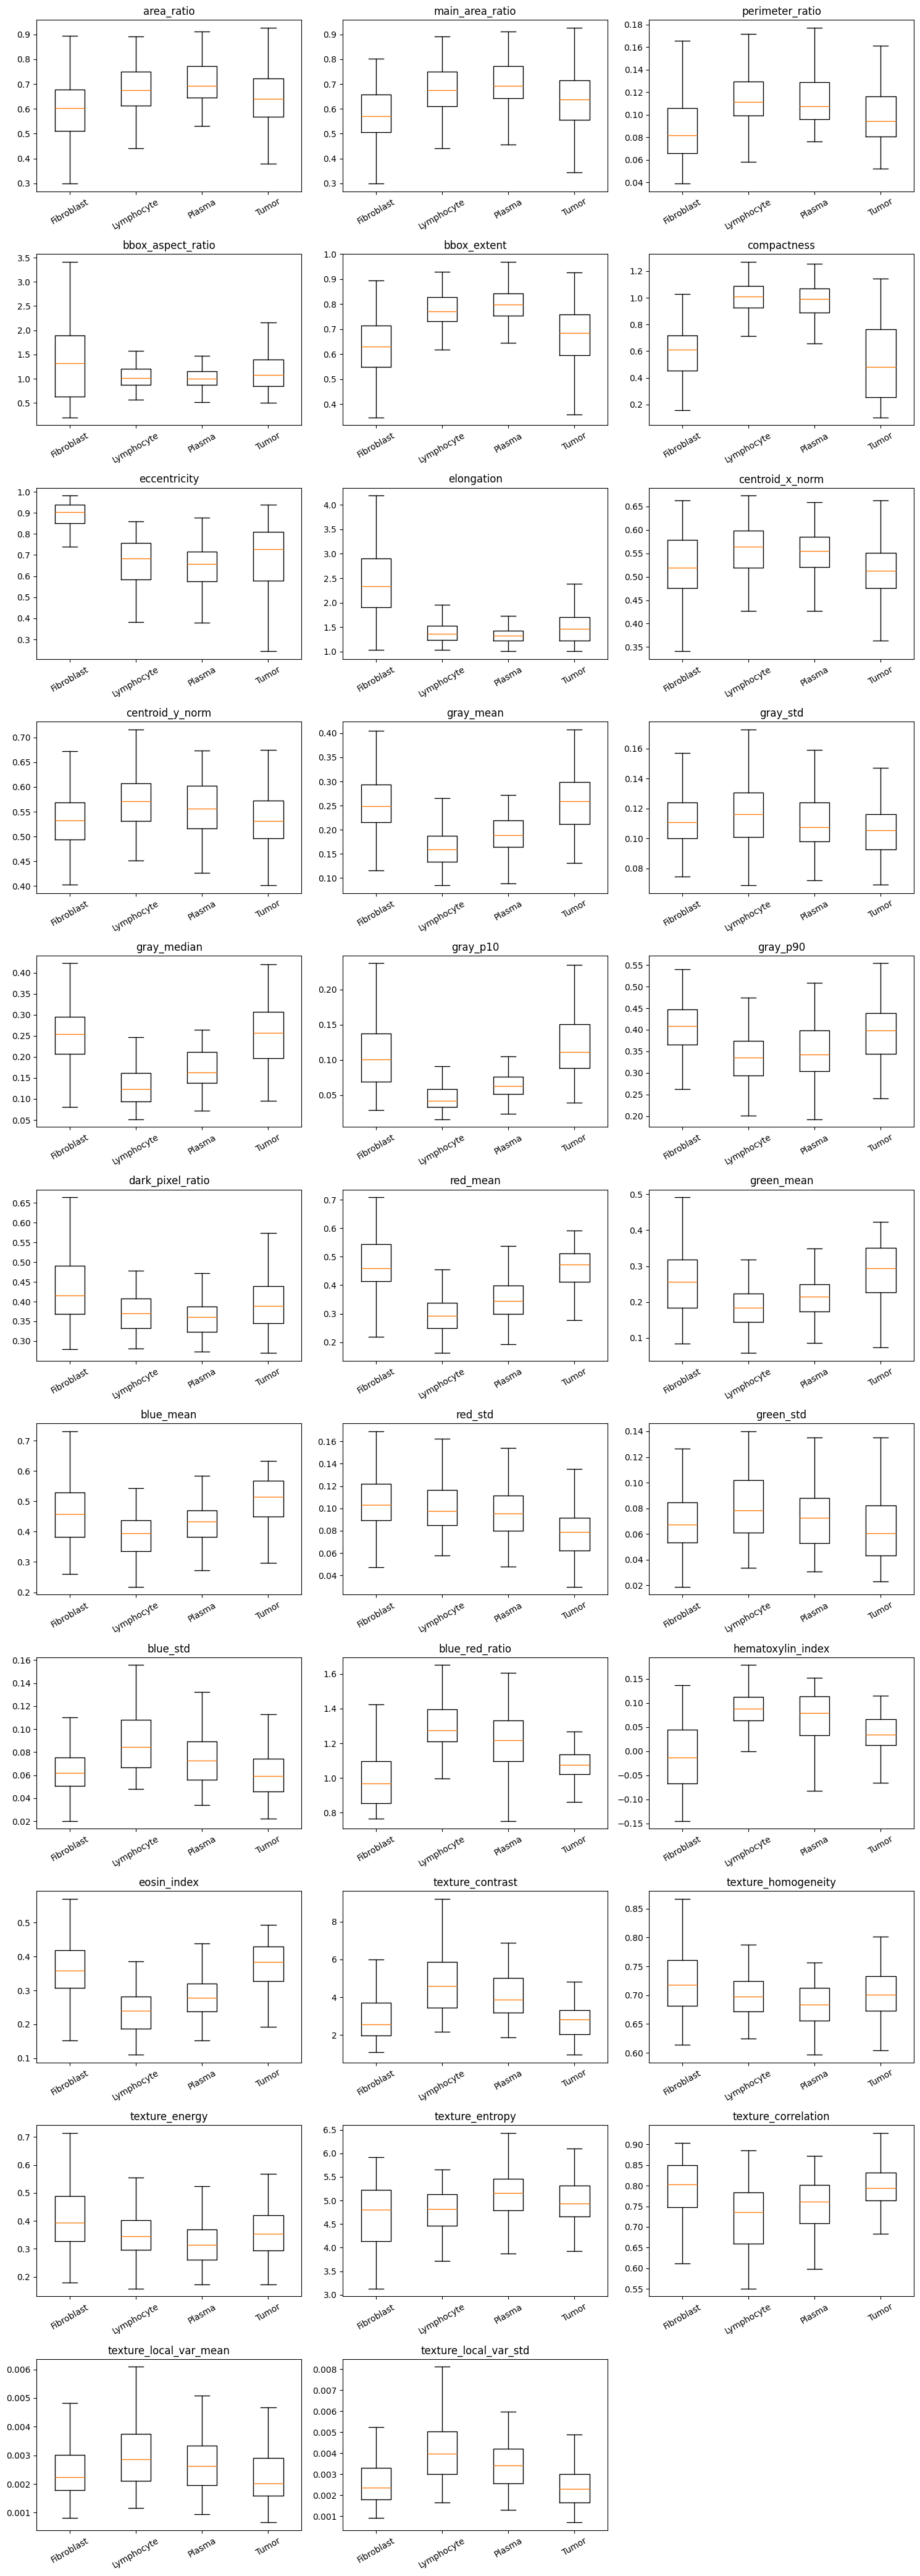

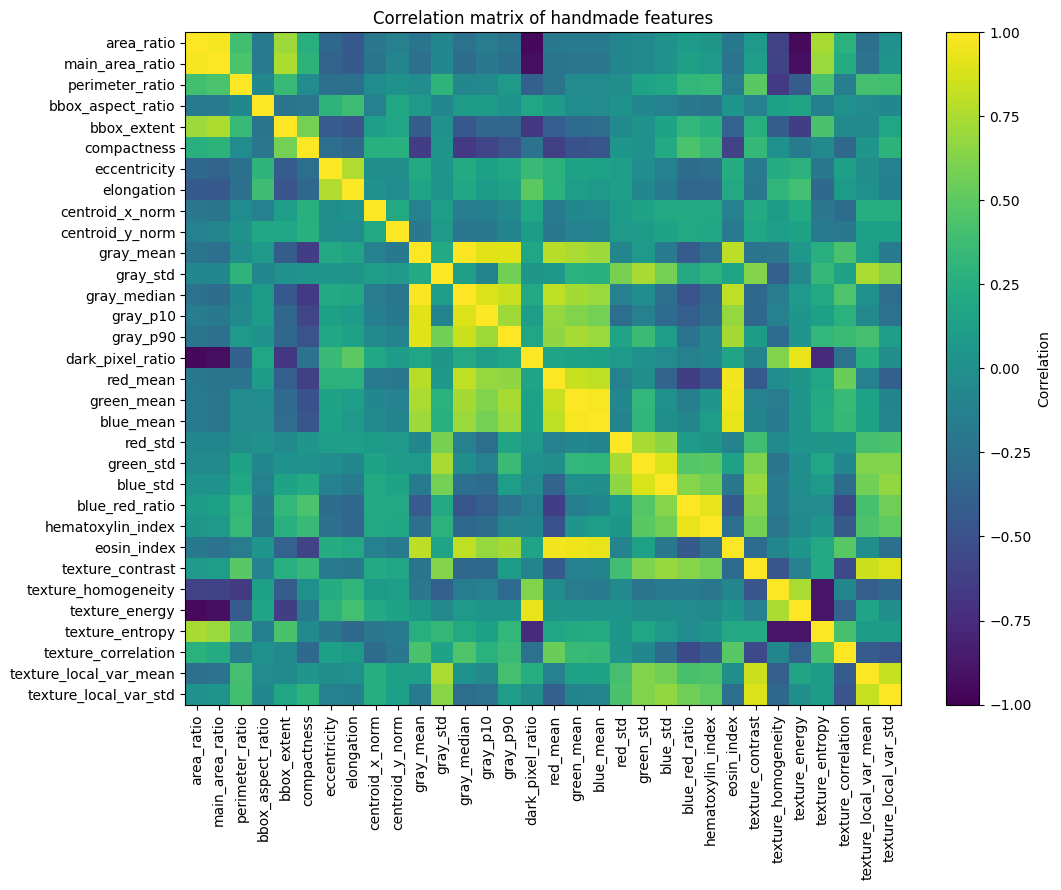

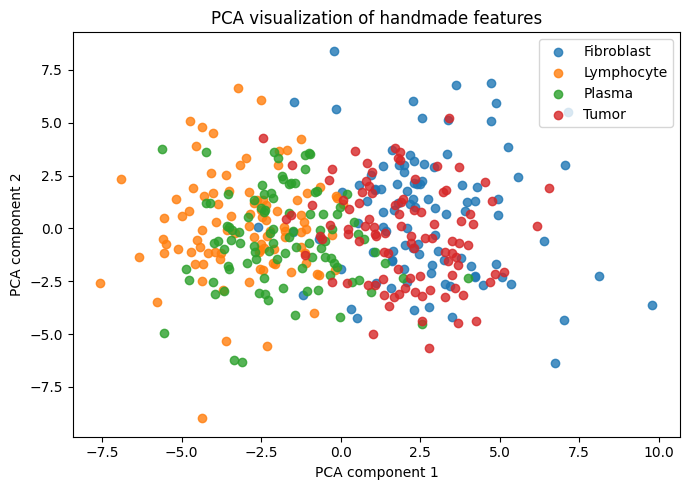

In [6]:
all_feature_cols = [
    col for col in features_df.columns
    if col not in ["Image", "Label"]
]

# Boxplots for every extracted descriptor, including texture descriptors.
n_cols = 3
n_rows = int(np.ceil(len(all_feature_cols) / n_cols))
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 3.8 * n_rows),
)
axes = axes.ravel()

for ax, feature in zip(axes, all_feature_cols):
    data_by_label = [
        features_df.loc[features_df["Label"] == label, feature].dropna()
        for label in label_names
    ]
    ax.boxplot(data_by_label, labels=label_names, showfliers=False)
    ax.set_title(feature)
    ax.tick_params(axis="x", rotation=30)

for ax in axes[len(all_feature_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "feature_boxplots_all.png"))
plt.show()

# Correlation heatmap.
corr = features_df[all_feature_cols].corr().fillna(0.0)
plt.figure(figsize=(11, 9))
plt.imshow(corr.values, vmin=-1, vmax=1, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(all_feature_cols)), all_feature_cols, rotation=90)
plt.yticks(range(len(all_feature_cols)), all_feature_cols)
plt.title("Correlation matrix of handmade features")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "feature_correlation_matrix.png"))
plt.show()

# PCA visualization with normalized features.
vis_df = features_df.dropna(subset=["Label"]).copy()
X_vis = vis_df[all_feature_cols].replace([np.inf, -np.inf], np.nan)
X_vis = X_vis.fillna(X_vis.median(numeric_only=True))
X_vis_scaled = StandardScaler().fit_transform(X_vis.values)
X_pca = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_vis_scaled)

plt.figure(figsize=(7, 5))
for label in label_names:
    idx = vis_df["Label"].values == label
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=label, alpha=0.8)

plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.title("PCA visualization of handmade features")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "feature_pca_scatter.png"))
plt.show()

## Part III — Classification

### Algorithm selection in simple English

We have only around 400 images and a compact set of handmade descriptors. So the
best models should be strong on small tabular datasets, should not require a lot
of computation, and should allow clear hyperparameter tuning.

The four selected models are:

1. **SVM with RBF kernel**  
   Pros: very strong for small/medium datasets, can model non-linear class
   borders, and it is directly connected to the maximum-margin idea seen in
   class. Cons: it is very sensitive to feature normalization and to `C` and
   `gamma`, so GridSearchCV is necessary.

2. **Random Forest**  
   Pros: good for non-linear relations, robust to feature interactions, and it
   gives useful feature-importance information. Cons: with only 400 images, deep
   trees can overfit, so the tree depth and leaf sizes must be tuned.

3. **K-Nearest Neighbors**  
   Pros: simple, fast to train, and a good baseline when we have few features.
   Cons: it is distance-based, so normalization is mandatory, and it can be
   sensitive to noisy or redundant descriptors. We tune `k`, distance weighting
   and the distance metric.

4. **Logistic Regression with L-BFGS**  
   Pros: very fast, stable on a normal laptop, interpretable, and the L-BFGS
   optimization algorithm is part of the optimization topics seen in class. Cons:
   the decision boundary is mainly linear, so it may miss complex class shapes.

Other algorithms are less ideal here as first choices. A single decision tree is
interpretable but unstable. Naive Bayes, LDA and QDA are very fast but rely more
on distribution assumptions. AdaBoost, Gradient Boosting and XGBoost can be
powerful, but they add more tuning and overfitting risk on only 400 samples.
LVQ is interesting but less directly available in standard scikit-learn.


### III.0 — Machine learning preparation

This is the common preparation cell for all four algorithms.

Important points handled here:

- **feature normalization:** `StandardScaler` is inside the pipeline;
- **feature selection:** `SelectKBest(f_classif)` is inside the pipeline;
- **hyperparameter tuning:** `GridSearchCV` is used for each model;
- **cross-validation:** `StratifiedKFold` keeps the label distribution in folds;
- **optimization:** each algorithm cell explains its own optimization logic.

Because the dataset is small, 5-fold stratified cross-validation is a good
compromise between stable scores and reasonable runtime on a normal laptop.


In [7]:
ml_df = pd.read_csv(FEATURES_TRAIN_CSV).dropna(subset=["Label"])

selected_feature_cols = [
    "area_ratio",
    "main_area_ratio",
    "perimeter_ratio",
    "compactness",
    "eccentricity",
    "bbox_aspect_ratio",
    "bbox_extent",
    "gray_mean",
    "gray_std",
    "dark_pixel_ratio",
    "red_mean",
    "green_mean",
    "blue_mean",
    "red_std",
    "blue_std",
    "blue_red_ratio",
    "texture_contrast",
]

missing_features = [
    col for col in selected_feature_cols
    if col not in ml_df.columns
]
if len(missing_features) > 0:
    raise ValueError(f"Missing selected features: {missing_features}")

feature_cols = selected_feature_cols
X = ml_df[feature_cols].replace([np.inf, -np.inf], np.nan).values
y = ml_df["Label"].values

n_features = len(feature_cols)
candidate_k_values = [8, 11, 14, n_features]
k_values = sorted(set(k for k in candidate_k_values if k <= n_features))

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

base_steps = [
    ("imputer", SimpleImputer(strategy="median")),
    ("variance", VarianceThreshold()),
    ("scaler", StandardScaler()),
    ("select", SelectKBest(score_func=f_classif)),
]

scoring_metric = "f1_weighted"
model_results = []
trained_searches = {}


def evaluate_predictions(model_name, y_true, y_pred, best_score, best_params):
    """Return the requested classification metrics."""
    return {
        "model": model_name,
        "best_cv_f1_weighted": float(best_score),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_weighted": precision_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0,
        ),
        "recall_weighted": recall_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0,
        ),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
        "best_params": best_params,
    }


def run_grid_model(model_name, classifier, param_grid):
    """Tune a model with GridSearchCV, then report CV predictions."""
    pipeline = Pipeline(base_steps + [("clf", classifier)])

    search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring=scoring_metric,
        cv=cv,
        n_jobs=-1,
        refit=True,
        return_train_score=False,
    )
    search.fit(X, y)

    # Cross-validated predictions using the best tuned pipeline.
    # This keeps the preprocessing inside each fold.
    preds = cross_val_predict(
        search.best_estimator_,
        X,
        y,
        cv=cv,
        n_jobs=-1,
    )

    result = evaluate_predictions(
        model_name=model_name,
        y_true=y,
        y_pred=preds,
        best_score=search.best_score_,
        best_params=search.best_params_,
    )

    cm = confusion_matrix(y, preds, labels=label_names)
    display_obj = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_names,
    )
    display_obj.plot(xticks_rotation=30)
    plt.title(f"Cross-validated confusion matrix: {model_name}")
    plt.tight_layout()
    fig_name = f"confusion_matrix_{model_name}.png"
    plt.savefig(os.path.join(FIG_DIR, fig_name))
    plt.show()

    return result, search


print("Selected features used for machine learning:")
for feature in feature_cols:
    print("-", feature)

print("\nNumber of selected features:", n_features)
print("Feature-selection k values tested:", k_values)

Selected features used for machine learning:
- area_ratio
- main_area_ratio
- perimeter_ratio
- compactness
- eccentricity
- bbox_aspect_ratio
- bbox_extent
- gray_mean
- gray_std
- dark_pixel_ratio
- red_mean
- green_mean
- blue_mean
- red_std
- blue_std
- blue_red_ratio
- texture_contrast

Number of selected features: 17
Feature-selection k values tested: [8, 11, 14, 17]


### III.1 — SVM with RBF kernel

**Optimization idea:** SVM searches for a separating rule with a large margin.
With the RBF kernel, the model can build non-linear borders. The most important
hyperparameters are `C`, controlling regularization, and `gamma`, controlling
the influence radius of each sample. Because SVM uses distances and margins,
feature normalization is essential.


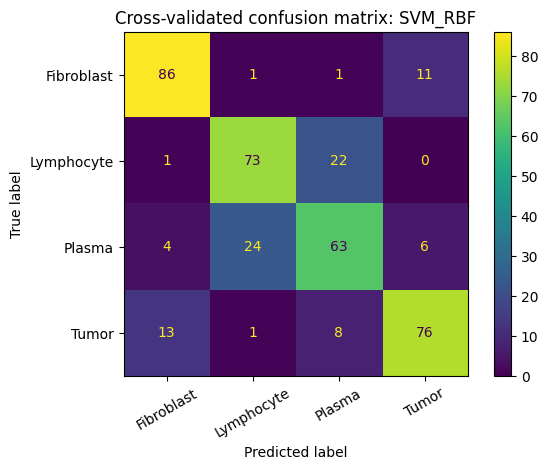

,model,best_cv_f1_weighted,accuracy,balanced_accuracy,precision_weighted,recall_weighted,f1_weighted,best_params
0,SVM_RBF,0.76307,0.764103,0.763525,0.763461,0.764103,0.76343,"{'clf__C': 100.0, 'clf__gamma': 0.01, 'select_..."


In [8]:
svm_classifier = SVC(
    kernel="rbf",
    class_weight="balanced",
    random_state=RANDOM_STATE,
)

svm_param_grid = {
    "select__k": k_values,
    "clf__C": [0.1, 1.0, 10.0, 100.0],
    "clf__gamma": ["scale", 0.01, 0.1, 1.0],
}

svm_result, svm_search = run_grid_model(
    "SVM_RBF",
    svm_classifier,
    svm_param_grid,
)

model_results.append(svm_result)
trained_searches["SVM_RBF"] = svm_search
display(pd.DataFrame([svm_result]))

### III.2 — Random Forest

**Optimization idea:** each tree greedily chooses splits that reduce impurity
(Gini or entropy). The forest averages many trees to reduce variance. It is not
very sensitive to scaling, but we keep the same pipeline for a fair comparison.
The key risk with 400 images is overfitting, so we tune the number of trees,
maximum depth, and minimum samples per leaf.


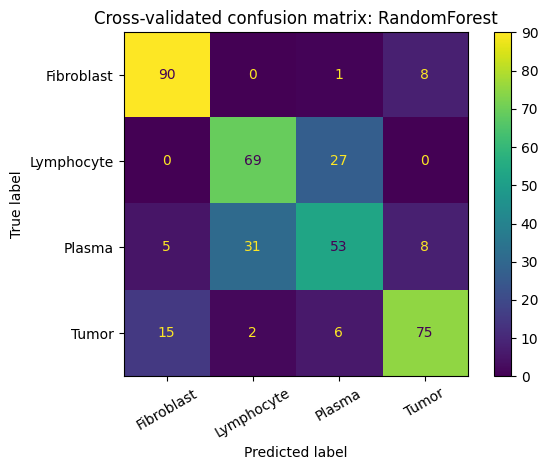

,model,best_cv_f1_weighted,accuracy,balanced_accuracy,precision_weighted,recall_weighted,f1_weighted,best_params
0,RandomForest,0.731148,0.735897,0.734885,0.732827,0.735897,0.732899,"{'clf__max_depth': None, 'clf__max_features': ..."


In [9]:
rf_classifier = RandomForestClassifier(
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_param_grid = {
    "select__k": k_values,
    "clf__n_estimators": [100, 200],
    "clf__max_depth": [None, 4, 8, 12],
    "clf__min_samples_leaf": [1, 2, 4],
    "clf__max_features": ["sqrt", None],
}

rf_result, rf_search = run_grid_model(
    "RandomForest",
    rf_classifier,
    rf_param_grid,
)

model_results.append(rf_result)
trained_searches["RandomForest"] = rf_search
display(pd.DataFrame([rf_result]))

### III.3 — K-Nearest Neighbors

**Optimization idea:** KNN does not learn weights during training. It is a
lazy, distance-based method. The optimization is therefore the model-selection
step: choosing the number of neighbors, the distance metric and the neighbor
weighting through cross-validation. Normalization is mandatory because features
have different units and ranges.


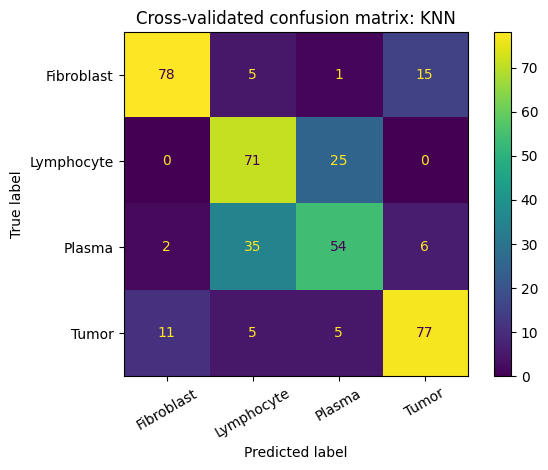

,model,best_cv_f1_weighted,accuracy,balanced_accuracy,precision_weighted,recall_weighted,f1_weighted,best_params
0,KNN,0.716174,0.717949,0.717469,0.72369,0.717949,0.718324,"{'clf__n_neighbors': 9, 'clf__p': 1, 'clf__wei..."


In [10]:
knn_classifier = KNeighborsClassifier()

knn_param_grid = {
    "select__k": k_values,
    "clf__n_neighbors": [3, 5, 7, 9, 11, 15],
    "clf__weights": ["uniform", "distance"],
    "clf__p": [1, 2],
}

knn_result, knn_search = run_grid_model(
    "KNN",
    knn_classifier,
    knn_param_grid,
)

model_results.append(knn_result)
trained_searches["KNN"] = knn_search
display(pd.DataFrame([knn_result]))

### III.4 — Logistic Regression with L-BFGS

**Optimization idea:** logistic regression minimizes a regularized
classification loss. The `lbfgs` solver is a limited-memory quasi-Newton method:
it is fast and memory-efficient for a small number of features. The main
hyperparameter is `C`, the inverse of regularization strength. A smaller `C`
means stronger regularization and can reduce overfitting.


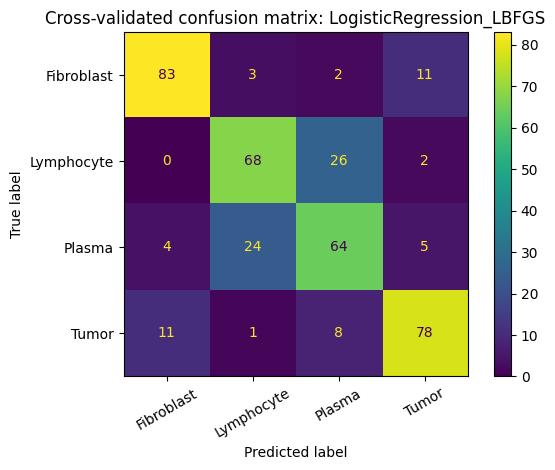

,model,best_cv_f1_weighted,accuracy,balanced_accuracy,precision_weighted,recall_weighted,f1_weighted,best_params
0,LogisticRegression_LBFGS,0.751052,0.751282,0.750607,0.752697,0.751282,0.751925,"{'clf__C': 100.0, 'select__k': 14}"


In [11]:
logreg_classifier = LogisticRegression(
    class_weight="balanced",
    max_iter=5000,
    random_state=RANDOM_STATE,
    solver="lbfgs",
)

logreg_param_grid = {
    "select__k": k_values,
    "clf__C": [0.01, 0.1, 1.0, 10.0, 100.0],
}

logreg_result, logreg_search = run_grid_model(
    "LogisticRegression_LBFGS",
    logreg_classifier,
    logreg_param_grid,
)

model_results.append(logreg_result)
trained_searches["LogisticRegression_LBFGS"] = logreg_search
display(pd.DataFrame([logreg_result]))

### III.5 — Model comparison and final training

We compare the four models using cross-validated metrics. The selected final
model is fitted again on all training samples, because after model selection we
want to use all available labeled data before the future test phase.


In [13]:
results_df = pd.DataFrame(model_results)
results_df = results_df.sort_values("f1_weighted", ascending=False)
display(results_df)

best_model_name = results_df.iloc[0]["model"]
best_search = trained_searches[best_model_name]
best_model = best_search.best_estimator_

print(f"Best model according to weighted F1: {best_model_name}")
print("Best parameters:")
print(best_search.best_params_)

best_model.fit(X, y)

saved_object = {
    "model": best_model,
    "feature_cols": feature_cols,
    "label_names": label_names,
    "results": results_df,
}
joblib.dump(saved_object, MODEL_PATH)

print(f"Saved final model to: {MODEL_PATH}")

,model,best_cv_f1_weighted,accuracy,balanced_accuracy,precision_weighted,recall_weighted,f1_weighted,best_params
0,SVM_RBF,0.763070,0.764103,0.763525,0.763461,0.764103,0.763430,"{'clf__C': 100.0, 'clf__gamma': 0.01, 'select_..."
3,LogisticRegression_LBFGS,0.751052,0.751282,0.750607,0.752697,0.751282,0.751925,"{'clf__C': 100.0, 'select__k': 14}"
1,RandomForest,0.731148,0.735897,0.734885,0.732827,0.735897,0.732899,"{'clf__max_depth': None, 'clf__max_features': ..."
2,KNN,0.716174,0.717949,0.717469,0.723690,0.717949,0.718324,"{'clf__n_neighbors': 9, 'clf__p': 1, 'clf__wei..."


Best model according to weighted F1: SVM_RBF
Best parameters:
{'clf__C': 100.0, 'clf__gamma': 0.01, 'select__k': 17}
Saved final model to: /workspaces/cell_classification/src/data/best_model.joblib


### Interpretation to complete after running

After running the notebook, complete this text using the displayed results:

- compare the weighted F1 scores of the four models;
- check balanced accuracy to ensure that the model does not ignore a class;
- inspect each confusion matrix to identify confused labels;
- explain whether the best model is also reasonable in terms of runtime and
  complexity.


## Part IV — Prediction on the future test set

This section is ready for the final test phase. When the test image folder is
available, the code extracts the same features, applies the saved model, and
creates a `test.csv` file with two columns: `Image` and `Label`.


In [14]:
def make_test_dataframe(test_img_dir):
    """Create a dataframe with test image identifiers."""
    valid_exts = (".png", ".jpg", ".jpeg", ".tif", ".tiff")
    image_files = [
        file_name for file_name in os.listdir(test_img_dir)
        if file_name.lower().endswith(valid_exts)
    ]
    image_files = sorted(image_files)
    image_ids = [os.path.splitext(file_name)[0] for file_name in image_files]
    return pd.DataFrame({"Image": image_ids})


def predict_test_set(test_img_dir, output_csv):
    """Extract test features and save predicted labels."""
    if not os.path.exists(test_img_dir):
        print("Test image folder not found. No prediction file created.")
        return None

    saved = joblib.load(MODEL_PATH)
    trained_model = saved["model"]
    saved_feature_cols = saved["feature_cols"]

    test_df = make_test_dataframe(test_img_dir)
    test_features_df = build_feature_table(
        test_df,
        test_img_dir,
        include_labels=False,
    )

    for col in saved_feature_cols:
        if col not in test_features_df.columns:
            test_features_df[col] = 0.0

    X_test = test_features_df[saved_feature_cols]
    X_test = X_test.replace([np.inf, -np.inf], np.nan).values
    predictions = trained_model.predict(X_test)

    output_df = pd.DataFrame({
        "Image": test_features_df["Image"].values,
        "Label": predictions,
    })
    output_df.to_csv(output_csv, index=False)

    print(f"Saved predictions to: {output_csv}")
    return output_df


if os.path.exists(TEST_IMG_DIR):
    test_predictions = predict_test_set(TEST_IMG_DIR, TEST_OUTPUT_CSV)
    display(test_predictions.head())
else:
    print("Test image folder is not available yet.")

Processed 50/400 images
Processed 100/400 images
Processed 150/400 images
Processed 200/400 images
Processed 250/400 images
Processed 300/400 images
Processed 350/400 images
Processed 400/400 images
Saved predictions to: /workspaces/cell_classification/src/data/test.csv


,Image,Label
0,00,Fibroblast
1,01,Tumor
2,02,Fibroblast
3,03,Lymphocyte
4,04,Lymphocyte


## Final checklist before submission

- Restart the kernel and run all cells.
- Check that there is no error message.
- Complete the short written analyses after the figures and the model results.
- Verify that `features_train.csv`, `best_model.joblib`, and eventually
  `test.csv` are created.
- Keep the notebook filename simple, with no spaces or special characters.
